# Comparative analysis: Leclerc vs Sainz – Q3 Monaco 2024

Objective: to identify where each driver gains time on their fastest lap, by overlaying telemetry data and a colour-coded circuit map.

**Author**: Marie Bouteyre
**Data**: FastF1

## 1. Setup and data loading

In [1]:
import fastf1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2024, 'Monaco', 'Q')
session.load()
circuit_info = session.get_circuit_info()

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']


## 2. Extracting fast laps and telemetry data

In [2]:

lec_lap = session.laps.pick_drivers('LEC').pick_fastest()
sai_lap = session.laps.pick_drivers('SAI').pick_fastest()

tel1 = lec_lap.get_telemetry()
tel2 = sai_lap.get_telemetry()

print(f"Leclerc : {lec_lap['LapTime']}")
print(f"Sainz   : {sai_lap['LapTime']}")
print(f"Delta   : {(sai_lap['LapTime'] - lec_lap['LapTime']).total_seconds():.3f} s")



Leclerc : 0 days 00:01:10.270000
Sainz   : 0 days 00:01:10.518000
Delta   : 0.248 s


## 3. Normalisation of distances travelled and calculation of the time difference

We begin by normalising the distances covered to avoid errors in comparison:
- Let L be the maximum distance covered by either driver
$$di_{norm} =\frac{di \times L}{di_{max}}$$

At each point on the track, we interpolate Sainz’s time over Leclerc’s distances and calculate the difference:

$$\Delta t(d) = t_{Lec}(d) - t_{Sainz}(d)$$

A **negative** delta means that Leclerc is ahead at that point.

In [3]:
# --- Calculation of the time delta ---
t1 = (tel1['Time'] - tel1['Time'].iloc[0]).dt.total_seconds().values
t2 = (tel2['Time'] - tel2['Time'].iloc[0]).dt.total_seconds().values
t1_max = tel1['Time'].dt.total_seconds().max()
d1 = tel1['Distance'].values
d2 = tel2['Distance'].values

# Standardise both distances to a common length
L = max(d1.max(), d2.max())
d1_norm = d1 * L / d1.max()
d2_norm = d2 * L / d2.max()

t2_interp = np.interp(d1_norm, d2_norm, t2)
delta_time = t1 - t2_interp
print(f"Final delta : {delta_time[-1]:.3f}")

Final delta : -0.248


## 4. Overlay of speeds and cumulative delta

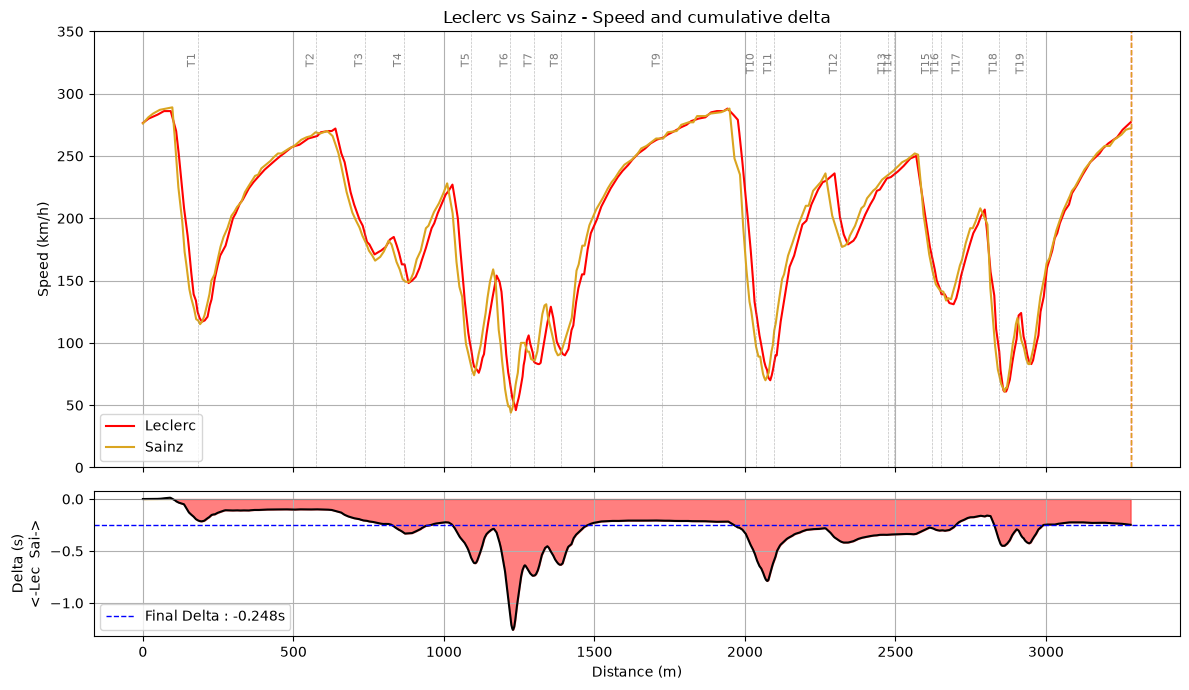

In [4]:
t1_max = t1.max()
t2_interp_max = t2.max()
delta_time_max = t1_max - t2_interp_max 

# --- Graph 1: speed + delta ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(d1_norm, tel1['Speed'], label='Leclerc', color='red')
ax1.plot(d2_norm, tel2['Speed'], label='Sainz', color='goldenrod')
ax1.set_ylabel('Speed (km/h)')
ax1.set_title('Leclerc vs Sainz - Speed and cumulative delta')

ax1.set_ylim(0, 350)
ax1.legend()
ax1.grid()

ax2.plot(d1_norm, delta_time, color='black', linewidth=1.5)
ax2.fill_between(d1_norm, delta_time, 0, where=(delta_time < 0), color='red', alpha=0.5)
ax2.fill_between(d1_norm, delta_time, 0, where=(delta_time >= 0), color='goldenrod', alpha=0.5)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Delta (s)\n<-Lec  Sai->')
ax2.grid()

#  Adds a vertical line and the number at each corner
for _, corner in circuit_info.corners.iterrows():
    txt = f"T{corner['Number']}{corner['Letter']}"
    ax1.axvline(x=corner['Distance'], color='gray', 
                linestyle='--', linewidth=0.5, alpha=0.5)
    ax1.text(corner['Distance'], ax1.get_ylim()[1] * 0.95, 
             txt, rotation=90, va='top', ha='right', 
             fontsize=8, color='gray')

lec_dis_norm_tot = d1_norm.max()
sai_dis_norm_tot = d2_norm.max()

ax1.axvline(x=lec_dis_norm_tot, color='red', linestyle='--', linewidth=1, alpha=1)
ax1.axvline(x=sai_dis_norm_tot, color='goldenrod', linestyle='--', linewidth=1, alpha=1)
ax2.axhline(y=delta_time_max, color='blue', linestyle='--', 
            linewidth=1, label=f'Final Delta : {delta_time[-1]:.3f}s')
ax2.legend(loc='lower left')


plt.tight_layout()
plt.show()


## 5. Colour-coded map of the circuit

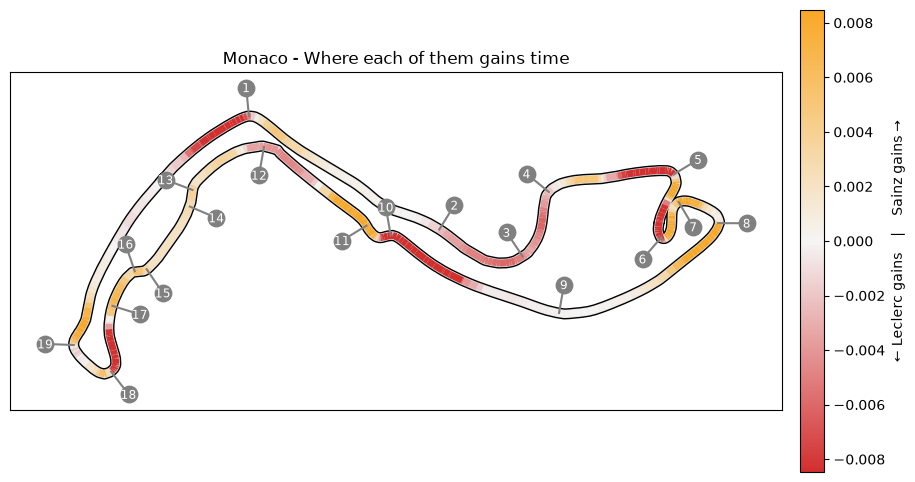

In [5]:
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.ndimage import uniform_filter1d
import numpy as np
import matplotlib.pyplot as plt


def rotate(xy, *, angle):
    rot_mat = np.array([[np.cos(angle), np.sin(angle)],
                        [-np.sin(angle), np.cos(angle)]])
    return np.matmul(xy, rot_mat)


# --- Retrieving positions ---
# tel1 must contain X and Y. If this is not the case:
# tel1 = lap1.get_telemetry().add_distance()
x = tel1['X'].values
y = tel1['Y'].values

# Rotation to ensure the circuit is correctly oriented
track_angle = circuit_info.rotation / 180 * np.pi
xy = np.array([x, y]).T
xy_rot = rotate(xy, angle=track_angle)
x_rot, y_rot = xy_rot[:, 0], xy_rot[:, 1]

# --- Construction of segments ---
points = np.array([x_rot, y_rot]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# --- Calculation of the local gain (smoothed delta, then derivative) ---
delta_smooth = uniform_filter1d(delta_time, size=20)
delta_diff = np.diff(delta_smooth)

# --- Colormap and normalisation ---
cmap = LinearSegmentedColormap.from_list(
    'lec_sai', ['#d32f2f', '#f5f5f5', '#f9a825']
)
vmax = np.percentile(np.abs(delta_diff), 70)
norm = plt.Normalize(vmin=-vmax, vmax=vmax)

# --- Circuit ---
fig, ax = plt.subplots(figsize=(12, 12))

# Circuit layout (below)
ax.plot(x_rot, y_rot, color='black', linewidth=8, zorder=1)
ax.plot(x_rot, y_rot, color='#e0e0e0', linewidth=6, zorder=2)

# Colourful LineCollection on top
lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=5, zorder=3)
lc.set_array(delta_diff)
ax.add_collection(lc)

# Colour bar
cbar = plt.colorbar(lc, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('← Leclerc gains    |    Sainz gains →')

# --- Corners numbering ---
offset_vector = [500, 0]
for _, corner in circuit_info.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    offset_angle = corner['Angle'] / 180 * np.pi
    offset_x, offset_y = rotate(offset_vector, angle=offset_angle)
    text_x = corner['X'] + offset_x
    text_y = corner['Y'] + offset_y
    text_x, text_y = rotate([text_x, text_y], angle=track_angle)
    track_x, track_y = rotate([corner['X'], corner['Y']], angle=track_angle)
    ax.scatter(text_x, text_y, color='grey', s=140, zorder=4)
    ax.plot([track_x, text_x], [track_y, text_y], color='grey', zorder=3)
    ax.text(text_x, text_y, txt, va='center_baseline', ha='center',
            size='small', color='white', zorder=5)

# --- Formatting ---
ax.set_title(f"{session.event['Location']} - Where each of them gains time")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
ax.autoscale()
plt.show()


## 6. Breakdown of a gap of -0.248s

During Q3 at Monaco in 2024, Charles Leclerc set the fastest qualifying time. With equal cars, we will compare his lap to that of his team-mate Carlos Sainz to determine how Leclerc built up his lead of -0.248s.

Although impressive on the cumulative delta graph, the peak at Turn 6 is not where Leclerc built the gap. In fact, the time gap before and after this sequence remains identical. This peak is due to differences in driving style between the two drivers. These are illustrated on the speed graph above: we can see that Leclerc opts for late braking followed by delayed acceleration, whilst Sainz brakes earlier, allowing him to accelerate sooner. These two choices reflect the classic trade-off between corner entry and exit; on this sequence, neither strategy gains the upper hand. This difference is clearly visible on the speed traces, which are similar in shape but offset from one another. The same applies between turns T10 and T11.

The gap actually builds up over two specific sections: the first part of the lap (T1 to T4, 0–900 m) and the final sequence from T18 to T19.

At Turn 3, Leclerc builds his lead by maintaining a higher speed than Sainz. His later and lighter braking allows him to take the apex at a higher speed than his team-mate. This build-up of his lead at this specific point is further illustrated on the circuit map showing where each driver gains time. Indeed, Turn 3 appears in red at both the entry and exit, whereas the sections mentioned above are red at the entry (Leclerc’s lead under braking) and then yellow at the exit (Sainz’s recovery during acceleration). It is from the point where they pass through T3 that Leclerc’s lead stabilises at around -0.250s, whereas previously it had fluctuated around -0.10s.
Leclerc thus builds the first part of his lead within the first thousand metres, having gained around 0.15s at this stage.

Finally, the gap reaches its final value of -0.248s following the T18-T19 sequence, where Leclerc gains a further 0.10s or so. The speed graph shows that Leclerc brakes later as he approaches T18. Unlike at T6, Sainz is unable to make up this time on the exit: the circuit map confirms this observation, with the entry to T18 marked in red and the exit in a neutral shade, indicating the absence of any recovery. This corner confirms the observation made at T3: in medium-speed corners, Leclerc’s late-braking style generates a net gain that is maintained, whilst it cancels itself out in very slow corners such as T6.

In conclusion, Leclerc’s final lead of -0.248s was built up in two stages: first at T3 with around 0.15s, then at T18 with a further 0.10s. These two corners share the common feature of being medium-speed corners, where Leclerc’s driving style proved beneficial. Conversely, Sainz’s style did not allow him to make up for Leclerc’s net gain on corner exit, unlike in the slow corners where their two styles ultimately cancel each other out.

One area for improvement for Sainz would be to delay his braking point in medium-speed corners, where his conservative approach costs him net time without any compensatory benefit on corner exit.